# Phase II Category-Level Analysis

This notebook examines whether cross-platform differences are consistent within broader app categories or are driven primarily by individual applications.

The analysis focuses on ratings, review length, low-signal comments, and cross-platform variation across the six study categories.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

APPLE_PATH = ROOT / "data" / "processed" / "apple_store_analysis.csv"
GOOGLE_PATH = ROOT / "data" / "processed" / "google_play_analysis.csv"

apple = pd.read_csv(APPLE_PATH)
google = pd.read_csv(GOOGLE_PATH)

apple["review_date"] = pd.to_datetime(
    apple["review_date"],
    errors="coerce",
    utc=True
)

google["review_date"] = pd.to_datetime(
    google["review_date"],
    errors="coerce",
    utc=True
)

apple["review_length"] = (
    apple["review_text"]
    .fillna("")
    .str.len()
)

google["review_length"] = (
    google["review_text"]
    .fillna("")
    .str.len()
)

print("Apple rows:", len(apple))
print("Google Play rows:", len(google))

Apple rows: 13599
Google Play rows: 13599


## 1. Category Validation

In [2]:
apple_categories = (
    apple.groupby("category")["app_name"]
    .nunique()
    .rename("Apple Apps")
)

google_categories = (
    google.groupby("category")["app_name"]
    .nunique()
    .rename("Google Play Apps")
)

category_validation = pd.concat(
    [apple_categories, google_categories],
    axis=1
)

display(category_validation)

print("\nApple categories:")
print(sorted(apple["category"].unique()))

print("\nGoogle Play categories:")
print(sorted(google["category"].unique()))

,Apple Apps,Google Play Apps
category,,
Education,4,4
Finance,4,4
Music & Audio,5,5
Productivity & Cloud,5,5
Social & Community,5,5
Travel & Mobility,5,5



Apple categories:
['Education', 'Finance', 'Music & Audio', 'Productivity & Cloud', 'Social & Community', 'Travel & Mobility']

Google Play categories:
['Education', 'Finance', 'Music & Audio', 'Productivity & Cloud', 'Social & Community', 'Travel & Mobility']


## 2. Category-Level Rating Comparison

In [3]:
apple_category_rating = (
    apple.groupby("category")["rating"]
    .mean()
    .rename("Apple Rating")
)

google_category_rating = (
    google.groupby("category")["rating"]
    .mean()
    .rename("Google Play Rating")
)

category_rating = pd.concat(
    [apple_category_rating, google_category_rating],
    axis=1
)

category_rating["Difference"] = (
    category_rating["Google Play Rating"]
    - category_rating["Apple Rating"]
)

category_rating["Absolute Difference"] = (
    category_rating["Difference"].abs()
)

category_rating = (
    category_rating
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
)

display(category_rating.round(2))

,Apple Rating,Google Play Rating,Difference,Absolute Difference
category,,,,
Social & Community,2.61,3.64,1.03,1.03
Finance,2.63,3.40,0.78,0.78
Productivity & Cloud,3.17,3.75,0.58,0.58
Travel & Mobility,3.31,3.71,0.40,0.40
Education,3.53,3.81,0.28,0.28
Music & Audio,3.83,3.87,0.05,0.05


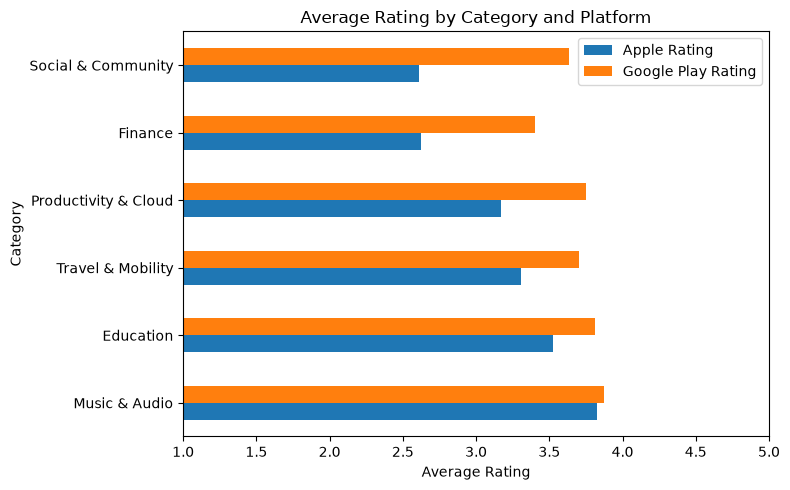

In [4]:
plot_data = (
    category_rating
    .sort_values(
        "Absolute Difference",
        ascending=True
    )
)

plot_data[
    ["Apple Rating", "Google Play Rating"]
].plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Average Rating by Category and Platform")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

## 3. Consistency of Platform Differences Within Categories

In [5]:
# App-level rating differences
apple_app_rating = (
    apple.groupby(["category", "app_name"])["rating"]
    .mean()
    .rename("Apple Rating")
)

google_app_rating = (
    google.groupby(["category", "app_name"])["rating"]
    .mean()
    .rename("Google Play Rating")
)

app_category_rating = pd.concat(
    [apple_app_rating, google_app_rating],
    axis=1
)

app_category_rating["Difference"] = (
    app_category_rating["Google Play Rating"]
    - app_category_rating["Apple Rating"]
)

display(
    app_category_rating.round(2)
)

Apple Rating  Google Play Rating  \
category             app_name                                               
Education            Coursera                    3.09                2.82   
                     Duolingo                    3.68                4.50   
                     Khan Academy                3.96                3.92   
                     Quizlet                     3.37                4.00   
Finance              Cash App                    3.50                3.98   
                     PayPal                      1.71                3.43   
                     Robinhood                   2.97                3.28   
                     Venmo                       1.68                2.94   
Music & Audio        Pandora                     4.28                3.31   
                     Shazam                      4.30                4.47   
                     SoundCloud                  4.33                4.23   
                     Spotify                     3.91                3.60   
                     YouTube Music               2.31                3.74   
Productivity & Cloud Dropbox                     3.35                3.46   
                     Google Drive                3.86                3.95   
                     Microsoft OneDrive          1.93                3.79   
                     Notion                      3.23                3.94   
                     Slack                       3.49                3.65   
Social & Community   Discord                     2.46                3.49   
                     Instagram                   2.77                3.78   
                     Pinterest                   2.69                4.20   
                     Reddit                      2.30                2.88   
                     TikTok                      2.83                3.84   
Travel & Mobility    Airbnb                      1.27                3.76   
                     Booking.com                 3.36                3.61   
                     Lyft                        4.08                3.23   
                     Uber                        3.99                3.87   
                     Waze                        3.85                4.06   

                                         Difference  
category             app_name                        
Education            Coursera                 -0.27  
                     Duolingo                  0.82  
                     Khan Academy             -0.04  
                     Quizlet                   0.63  
Finance              Cash App                  0.48  
                     PayPal                    1.72  
                     Robinhood                 0.30  
                     Venmo                     1.26  
Music & Audio        Pandora                  -0.98  
                     Shazam                    0.17  
                     SoundCloud               -0.10  
                     Spotify                  -0.31  
                     YouTube Music             1.44  
Productivity & Cloud Dropbox                   0.11  
                     Google Drive              0.08  
                     Microsoft OneDrive        1.87  
                     Notion                    0.71  
                     Slack                     0.15  
Social & Community   Discord                   1.03  
                     Instagram                 1.01  
                     Pinterest                 1.51  
                     Reddit                    0.58  
                     TikTok                    1.01  
Travel & Mobility    Airbnb                    2.49  
                     Booking.com               0.25  
                     Lyft                     -0.85  
                     Uber                     -0.12  
                     Waze                      0.21

In [6]:
category_consistency = (
    app_category_rating
    .groupby("category")["Difference"]
    .agg(
        app_count="count",
        mean_difference="mean",
        median_difference="median",
        min_difference="min",
        max_difference="max"
    )
)

category_consistency["Google Higher Apps"] = (
    app_category_rating["Difference"]
    .gt(0)
    .groupby(level="category")
    .sum()
)

category_consistency["Apple Higher Apps"] = (
    app_category_rating["Difference"]
    .lt(0)
    .groupby(level="category")
    .sum()
)

category_consistency = (
    category_consistency
    .sort_values(
        "mean_difference",
        ascending=False
    )
)

display(
    category_consistency.round(2)
)

,app_count,mean_difference,median_difference,min_difference,max_difference,Google Higher Apps,Apple Higher Apps
category,,,,,,,
Social & Community,5,1.03,1.01,0.58,1.51,5,0
Finance,4,0.94,0.87,0.30,1.72,4,0
Productivity & Cloud,5,0.59,0.15,0.08,1.87,5,0
Travel & Mobility,5,0.40,0.21,-0.85,2.49,3,2
Education,4,0.28,0.29,-0.27,0.82,2,2
Music & Audio,5,0.05,-0.10,-0.98,1.44,2,3


### Category Consistency Findings

- Social & Community shows the strongest category-level pattern: all five apps have higher average ratings on Google Play, with a mean cross-platform difference of 1.03 rating points.
- Finance is also highly consistent, with all four apps rated higher on Google Play and a mean difference of 0.94 points.
- Productivity & Cloud is directionally consistent, with all five apps rated higher on Google Play. However, the median difference is only 0.15 compared with a mean difference of 0.59, suggesting that the category average is partly amplified by a small number of large-gap apps such as Microsoft OneDrive.
- Travel & Mobility and Education show mixed directions across individual apps, so their category averages should not be interpreted as consistent platform effects.
- Music & Audio shows almost no overall platform difference and contains substantial app-level variation in both directions.
- These results indicate that some cross-platform patterns appear relatively consistent within categories, while others are driven primarily by specific applications.
- For product and business teams, category-level benchmarks may be useful for Social & Community and Finance, but app-level analysis remains necessary because broader averages can hide important exceptions.

## 4. Category Patterns and Time-Window Limitations

In [7]:
apple_time = (
    apple.groupby(["category", "app_name"])["review_date"]
    .agg(["min", "max"])
)

google_time = (
    google.groupby(["category", "app_name"])["review_date"]
    .agg(["min", "max"])
)

apple_time["Apple Coverage Days"] = (
    apple_time["max"] - apple_time["min"]
).dt.total_seconds() / 86400

google_time["Google Coverage Days"] = (
    google_time["max"] - google_time["min"]
).dt.total_seconds() / 86400


category_time_check = (
    app_category_rating
    .join(
        apple_time[["Apple Coverage Days"]]
    )
    .join(
        google_time[["Google Coverage Days"]]
    )
)

category_time_check["Coverage Mismatch Ratio"] = (
    category_time_check[
        ["Apple Coverage Days", "Google Coverage Days"]
    ].max(axis=1)
    /
    category_time_check[
        ["Apple Coverage Days", "Google Coverage Days"]
    ].min(axis=1)
)

display(
    category_time_check.loc[
        ["Social & Community", "Finance"]
    ].round(2)
)

Apple Rating  Google Play Rating  Difference  \
category           app_name                                                  
Social & Community Discord            2.46                3.49        1.03   
                   Instagram          2.77                3.78        1.01   
                   Pinterest          2.69                4.20        1.51   
                   Reddit             2.30                2.88        0.58   
                   TikTok             2.83                3.84        1.01   
Finance            Cash App           3.50                3.98        0.48   
                   PayPal             1.71                3.43        1.72   
                   Robinhood          2.97                3.28        0.30   
                   Venmo              1.68                2.94        1.26   

                              Apple Coverage Days  Google Coverage Days  \
category           app_name                                               
Social & Community Discord                   9.68                  3.19   
                   Instagram                 4.95                  0.24   
                   Pinterest                13.63                  2.63   
                   Reddit                   14.41                  3.86   
                   TikTok                    4.49                  0.77   
Finance            Cash App                 17.72                  5.03   
                   PayPal                   23.11                  1.69   
                   Robinhood                43.81                 32.25   
                   Venmo                    12.03                  6.18   

                              Coverage Mismatch Ratio  
category           app_name                            
Social & Community Discord                       3.04  
                   Instagram                    20.75  
                   Pinterest                     5.19  
                   Reddit                        3.74  
                   TikTok                        5.86  
Finance            Cash App                      3.52  
                   PayPal                       13.66  
                   Robinhood                     1.36  
                   Venmo                         1.95

### Time-Window Sensitivity Findings

- Social & Community shows a highly consistent rating direction, with all five apps rated higher on Google Play. However, timestamp coverage differs substantially across platforms for every app in this category, including especially large mismatches for Instagram, TikTok, and Pinterest.
- The Social & Community pattern is therefore descriptively strong but should be interpreted cautiously as a platform-level effect.
- Finance also shows consistently higher Google Play ratings across all four apps.
- Importantly, Venmo and Robinhood have relatively comparable time windows and still show higher Google Play ratings, providing stronger support that the Finance pattern is not driven entirely by timestamp mismatch.
- However, large time-window differences for PayPal and Cash App may inflate the category-level average difference.
- These results reinforce the importance of combining direction consistency with time-window comparability before interpreting cross-platform patterns.

## 5. Sensitivity Analysis Using More Comparable Time Windows

In [8]:
sensitivity_data = category_time_check.copy()

# Relatively comparable time windows
low_mismatch = sensitivity_data[
    sensitivity_data["Coverage Mismatch Ratio"] <= 2
]

moderate_mismatch = sensitivity_data[
    sensitivity_data["Coverage Mismatch Ratio"] <= 5
]


low_summary = (
    low_mismatch
    .groupby(level="category")["Difference"]
    .agg(
        app_count="count",
        mean_difference="mean",
        median_difference="median"
    )
)

moderate_summary = (
    moderate_mismatch
    .groupby(level="category")["Difference"]
    .agg(
        app_count="count",
        mean_difference="mean",
        median_difference="median"
    )
)


print("Apps with Coverage Mismatch Ratio <= 2:")
display(low_summary.round(2))

print("\nApps with Coverage Mismatch Ratio <= 5:")
display(moderate_summary.round(2))

Apps with Coverage Mismatch Ratio <= 2:


,app_count,mean_difference,median_difference
category,,,
Education,1,-0.04,-0.04
Finance,2,0.78,0.78
Music & Audio,2,-0.54,-0.54
Productivity & Cloud,1,0.15,0.15
Travel & Mobility,1,-0.85,-0.85



Apps with Coverage Mismatch Ratio <= 5:


,app_count,mean_difference,median_difference
category,,,
Education,3,0.11,-0.04
Finance,3,0.68,0.48
Music & Audio,4,-0.30,-0.20
Productivity & Cloud,3,0.33,0.15
Social & Community,2,0.80,0.80
Travel & Mobility,4,-0.13,0.04


## 6. Category-Level Review Quality

In [9]:
category_quality_rows = []

for category in sorted(apple["category"].unique()):

    apple_cat = apple[
        apple["category"] == category
    ]

    google_cat = google[
        google["category"] == category
    ]

    category_quality_rows.append({
        "category": category,

        "Apple Median Length":
            apple_cat["review_length"].median(),

        "Google Median Length":
            google_cat["review_length"].median(),

        "Apple <=20 Char (%)":
            (apple_cat["review_length"] <= 20).mean() * 100,

        "Google <=20 Char (%)":
            (google_cat["review_length"] <= 20).mean() * 100,

        "Apple Repeated Text (%)":
            apple_cat["review_text"].duplicated().mean() * 100,

        "Google Repeated Text (%)":
            google_cat["review_text"].duplicated().mean() * 100
    })


category_quality = (
    pd.DataFrame(category_quality_rows)
    .set_index("category")
)

display(category_quality.round(2))

,Apple Median Length,Google Median Length,Apple <=20 Char (%),Google <=20 Char (%),Apple Repeated Text (%),Google Repeated Text (%)
category,,,,,,
Education,114.0,47.0,11.20,28.30,1.15,8.80
Finance,116.0,58.0,14.67,27.15,2.00,7.21
Music & Audio,78.0,25.0,18.16,45.44,1.92,16.52
Productivity & Cloud,100.0,40.0,16.00,37.39,2.45,15.67
Social & Community,126.0,34.0,11.44,39.94,0.92,14.05
Travel & Mobility,96.0,38.0,14.96,34.24,2.48,13.56


### Category-Level Review Quality Findings

- Review-quality differences are highly consistent across all six categories.
- Apple App Store has a higher median review length than Google Play in every category.
- Google Play has a substantially higher share of reviews with 20 characters or fewer across every category.
- Repeated review text is also more common on Google Play in every category.
- The largest short-review rates on Google Play appear in Music & Audio, Social & Community, and Productivity & Cloud.
- Unlike the rating results, which vary considerably across apps and categories, review-length and low-signal patterns appear much more consistent across the dataset.
- This suggests that platform-specific preprocessing may be important for downstream sentiment and product analysis.

### Business Implication

For product teams, Apple reviews may provide richer issue-level context per review, while Google Play data may require stronger filtering for short or repetitive comments before text-based analysis. This does not necessarily mean one platform is a better source overall, but it suggests that the two platforms may require different preprocessing and interpretation strategies.

The observed text-length difference may reflect a combination of user behavior, platform design, and collection characteristics, so it should not be interpreted as a causal platform effect.

In [10]:
category_quality_comparison = category_quality.copy()

category_quality_comparison["Median Length Ratio (Apple/Google)"] = (
    category_quality_comparison["Apple Median Length"]
    / category_quality_comparison["Google Median Length"]
)

category_quality_comparison["Short Review Gap (Google-Apple)"] = (
    category_quality_comparison["Google <=20 Char (%)"]
    - category_quality_comparison["Apple <=20 Char (%)"]
)

category_quality_comparison["Repeated Text Gap (Google-Apple)"] = (
    category_quality_comparison["Google Repeated Text (%)"]
    - category_quality_comparison["Apple Repeated Text (%)"]
)

display(
    category_quality_comparison[
        [
            "Median Length Ratio (Apple/Google)",
            "Short Review Gap (Google-Apple)",
            "Repeated Text Gap (Google-Apple)"
        ]
    ].round(2)
)

,Median Length Ratio (Apple/Google),Short Review Gap (Google-Apple),Repeated Text Gap (Google-Apple)
category,,,
Education,2.43,17.10,7.65
Finance,2.00,12.48,5.21
Music & Audio,3.12,27.28,14.60
Productivity & Cloud,2.50,21.39,13.22
Social & Community,3.71,28.49,13.13
Travel & Mobility,2.53,19.28,11.08


## 7. Category-Level Takeaways

### Strongest Findings

1. **Review-quality differences are highly consistent across categories.**  
   Apple App Store reviews have a higher median review length in all six categories, ranging from approximately 2.0 to 3.7 times the Google Play median.

2. **Short reviews are consistently more common on Google Play.**  
   The Google Play share of reviews with 20 characters or fewer is higher in every category, with the largest gaps appearing in Social & Community and Music & Audio.

3. **Repeated review text is also consistently more common on Google Play.**  
   The largest repeated-text gaps appear in Music & Audio, Productivity & Cloud, and Social & Community.

4. **Rating patterns are less consistent than review-quality patterns.**  
   Finance provides the strongest evidence of a relatively stable Google-higher rating pattern, while Social & Community is suggestive but affected by substantial time-window mismatch. Other categories show meaningful app-level variation.

### Business Implication

For product teams, platform choice may affect not only observed sentiment but also the amount of diagnostic information contained in each review. Apple reviews may provide richer written context per review, while Google Play may require stronger filtering of short or repetitive feedback before text-based sentiment or product analysis.

At the same time, Google Play may represent a more concentrated and recent stream of reviews for some applications. The two sources should therefore be treated as complementary rather than ranked solely by review richness.

### Limitation

These findings describe patterns in the collected sample and do not establish that platform design causes the observed differences. Review timing, user populations, app-specific events, and collection characteristics may also contribute.